In [35]:
import os



import nrrd
import matplotlib.pyplot as plt

import json
import os
from pathlib import Path
from typing import Tuple, Dict, Any, List

import numpy as np

In [7]:
file_path = Path("/Volumes/warm_archiv/CT-Data/3dseg/data/NEAPEL/neapel_002/Thinlayer 2-2_2023-04-28_124148/tomo-HR/Thinlayer 2-2_tomo-HR_recon_aligned_uint8.nrrd")

In [ ]:
vol, header = nrrd.read(str(file_path))
print(header)
print(vol.shape,vol.dtype)

OrderedDict([('type', 'uint8'), ('dimension', 3), ('space', 'left-posterior-superior'), ('sizes', array([1980, 2026, 2009])), ('space directions', array([[1.48122919, 0.        , 0.        ],
       [0.        , 1.48122919, 0.        ],
       [0.        , 0.        , 1.48122919]])), ('kinds', ['domain', 'domain', 'domain']), ('encoding', 'gzip'), ('space origin', array([0.        , 0.        , 1.48122919]))])


In [10]:
print(header.shape)

(1980, 2026, 2009)


In [71]:
subvolume = vol[400:1600,300:1700,400:1600]

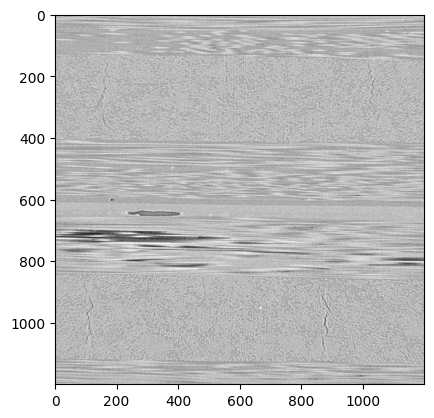

In [72]:
plt.imshow(subvolume[:,-1,:],cmap="grey",vmax=70)

In [73]:
def save_tiff(path: str, img2d: np.ndarray) -> None:
    """
    Saves a 2D patch as TIFF (uint8/uint16 supported).
    """
    import tifffile  # pip install tifffile
    tifffile.imwrite(path, img2d)

# --- slicing / patch extraction ----------------------------------------------
def get_plane_slice(vol: np.ndarray, plane: str, index: int) -> np.ndarray:
    """
    vol is assumed (Z,Y,X).
    plane:
      - 'xy': fixed z = index -> (Y,X)
      - 'xz': fixed y = index -> (Z,X)
      - 'yz': fixed x = index -> (Z,Y)
    Returns a 2D array view.
    """
    if vol.ndim != 3:
        raise ValueError(f"Expected 3D volume, got shape {vol.shape}")

    Z, Y, X = vol.shape
    if plane == "xy":
        if not (0 <= index < Z): raise IndexError(f"z index {index} out of range [0,{Z-1}]")
        return vol[index, :, :]
    if plane == "xz":
        if not (0 <= index < Y): raise IndexError(f"y index {index} out of range [0,{Y-1}]")
        return vol[:, index, :]
    if plane == "yz":
        if not (0 <= index < X): raise IndexError(f"x index {index} out of range [0,{X-1}]")
        return vol[:, :, index]
    raise ValueError("plane must be one of: xy, xz, yz")

def extract_patches_from_2d(img: np.ndarray, patch: int, stride: int) -> List[Tuple[int,int,np.ndarray]]:
    """
    Returns list of (row, col, patch_img) where (row,col) is top-left in the 2D slice.
    """
    H, W = img.shape
    out = []
    for r in range(0, H - patch + 1, stride):
        for c in range(0, W - patch + 1, stride):
            out.append((r, c, img[r:r+patch, c:c+patch].copy()))
    return out

In [80]:
out_dir = file_path.parent / "patches"

print(out_dir)

out_dir.mkdir(parents=True, exist_ok=True)

/Volumes/warm_archiv/CT-Data/3dseg/data/NEAPEL/neapel_002/Thinlayer 2-2_2023-04-28_124148/tomo-HR/patches


In [82]:
if subvolume.ndim != 3:
    raise ValueError(f"Expected 3D volume, got {subvolume.ndim}D with shape {subvolume.shape}")
Z, Y, X = subvolume.shape


plane = "xz"
slice_indices = ""
num_slices = 30
seed = 42
# pick slices
rng = np.random.default_rng(seed)
if slice_indices.strip():
    slice_indices = [int(s.strip()) for s in slice_indices.split(",") if s.strip()]
else:
    axis_len = {"xy": Z, "xz": Y, "yz": X}[plane]
    if num_slices > axis_len:
        num_slices = axis_len
    slice_indices = rng.choice(axis_len, size=num_slices, replace=False).tolist()

print(f"Extracting patches from plane {plane} at slices {slice_indices}")

Extracting patches from plane xz at slices [1395, 727, 595, 1181, 122, 129, 254, 1150, 1089, 960, 177, 277, 1348, 711, 1166, 1090, 516, 1017, 562, 603, 620, 763, 626, 695, 1061, 1291, 993, 898, 118, 1053]


In [83]:
base = Path(file_path).stem
print(f"basename of file_path: {base}")

basename of file_path: Thinlayer 2-2_tomo-HR_recon_aligned_uint8


In [84]:
records = []
base = Path(file_path).stem

patch = 256
stride =128
max_patches = 100

idx = 0
for si in slice_indices:
    slice2d = get_plane_slice(subvolume, plane, si)
    patches = extract_patches_from_2d(slice2d, patch=patch, stride=stride)

    if max_patches and len(patches) > max_patches:
        idx = rng.choice(len(patches), size=max_patches, replace=False)
        patches = [patches[i] for i in idx]

    for k, (r, c, pimg) in enumerate(patches):
        fname = f"patch{idx:04d}.tiff"
        fpath = out_dir / fname
        save_tiff(str(fpath), pimg)
        idx += 1

        # Coordinates stored in volume index space (Z,Y,X), plus 2D slice coords.
        # For super-res prototyping, this is usually what you want.
        rec = {
            "file": fname,
            "plane": plane,
            "slice_index": si,
            "patch_size": patch,
            "stride": stride,
            "top_left_rc": [int(r), int(c)],         # in slice 2D coordinates
            "shape_2d": [int(pimg.shape[0]), int(pimg.shape[1])],
        }

        # Map (r,c) back to volume indices for reproducibility:
        # vol is (Z,Y,X)
        if plane == "xy":
            rec["vol_bbox_zyx"] = {
                "z": [int(si), int(si)],
                "y": [int(r), int(r + patch - 1)],
                "x": [int(c), int(c + patch - 1)],
            }
        elif plane == "xz":
            # slice is (Z,X): r->z, c->x, fixed y=si
            rec["vol_bbox_zyx"] = {
                "z": [int(r), int(r + patch - 1)],
                "y": [int(si), int(si)],
                "x": [int(c), int(c + patch - 1)],
            }
        else:  # yz
            # slice is (Z,Y): r->z, c->y, fixed x=si
            rec["vol_bbox_zyx"] = {
                "z": [int(r), int(r + patch - 1)],
                "y": [int(c), int(c + patch - 1)],
                "x": [int(si), int(si)],
            }

        records.append(rec)

json_out = out_dir / f"{base}_patches_{plane}.json"
payload = {
    "input_nrrd": os.path.abspath(file_path),
    "volume_shape_zyx": [int(Z), int(Y), int(X)],
    # "meta": header,
    "config": {
        "plane": plane,
        "slice_indices": slice_indices,
        "patch": patch,
        "stride": stride,
        "max_patches": max_patches,
        "seed": seed,
    },
    "patches": records,
}
json_out.write_text(json.dumps(payload, indent=2))
print(f"Saved {len(records)} patches to: {out_dir}")
print(f"Wrote metadata JSON: {json_out}")

Saved 1920 patches to: /Volumes/warm_archiv/CT-Data/3dseg/data/NEAPEL/neapel_002/Thinlayer 2-2_2023-04-28_124148/tomo-HR/patches
Wrote metadata JSON: /Volumes/warm_archiv/CT-Data/3dseg/data/NEAPEL/neapel_002/Thinlayer 2-2_2023-04-28_124148/tomo-HR/patches/Thinlayer 2-2_tomo-HR_recon_aligned_uint8_patches_xz.json
